# Lorenz Long-Run Benchmark: Steps vs RAM

This notebook benchmarks **Lorenz RK4 long runs** and produces scatter plots:

- x-axis: integration steps
- y-axis: RAM usage (process RSS in MB)

Requested sweep:

- from **50,000** to **1,000,000** steps, increment **50,000**
- then from **1,500,000** to **10,000,000** steps, increment **500,000**

The run is resumable via CSV checkpoints because this sweep is very heavy.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys
import os
import gc
import csv
import time
import threading

import numpy as np
import matplotlib.pyplot as plt
import psutil
from IPython.display import display

try:
    import pandas as pd  # optional
except Exception:
    pd = None

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "core").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "core").exists():
            PROJECT_ROOT = parent
            break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from core.solver import integrate_system_rk4
from core.lorenz_system_rhs import lorenz_rhs

print(f"Project root: {PROJECT_ROOT}")
print(f"pandas available: {pd is not None}")


Project root: /home/odygoundi/Documents/nds-simulator
pandas available: True


In [2]:
# -------------------------
# Benchmark configuration
# -------------------------
DT = 0.01
Y0 = np.array([1.0, 1.0, 1.0], dtype=float)

STEP_FINE = np.arange(50_000, 1_000_000 + 1, 50_000, dtype=np.int64)
STEP_COARSE = np.arange(1_500_000, 10_000_000 + 1, 500_000, dtype=np.int64)
STEP_VALUES = np.concatenate([STEP_FINE, STEP_COARSE])

# Keep this bounded to benchmark memory-safe behavior.
# Set to None for unbounded/full storage (may OOM on large runs).
MAX_STORE_STEPS = 200_000

MONITOR_INTERVAL_S = 0.02
RESUME = True

RESULTS_DIR = PROJECT_ROOT / "tests" / "benchmarks"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

mode_label = "unbounded" if MAX_STORE_STEPS is None else f"bounded_{int(MAX_STORE_STEPS)}"
RESULTS_CSV = RESULTS_DIR / f"lorenz_ram_vs_steps_{mode_label}.csv"

print(f"N points in sweep: {len(STEP_VALUES)}")
print(f"Steps range: {STEP_VALUES[0]:,} -> {STEP_VALUES[-1]:,}")
print(f"Fine segment: {STEP_FINE[0]:,} -> {STEP_FINE[-1]:,} (delta 50,000)")
print(f"Coarse segment: {STEP_COARSE[0]:,} -> {STEP_COARSE[-1]:,} (delta 500,000)")
print(f"Mode: {mode_label}")
print(f"CSV path: {RESULTS_CSV}")


N points in sweep: 38
Steps range: 50,000 -> 10,000,000
Fine segment: 50,000 -> 1,000,000 (delta 50,000)
Coarse segment: 1,500,000 -> 10,000,000 (delta 500,000)
Mode: bounded_200000
CSV path: /home/odygoundi/Documents/nds-simulator/tests/benchmarks/lorenz_ram_vs_steps_bounded_200000.csv


In [3]:
COLUMNS = [
    "n_steps",
    "dt",
    "tf",
    "mode",
    "max_store_steps",
    "stored_samples",
    "baseline_rss_mb",
    "peak_rss_mb",
    "delta_peak_mb",
    "end_rss_mb",
    "post_gc_rss_mb",
    "elapsed_s",
    "timestamp",
]

INT_FIELDS = {"n_steps", "max_store_steps", "stored_samples"}
FLOAT_FIELDS = {
    "dt", "tf", "baseline_rss_mb", "peak_rss_mb", "delta_peak_mb",
    "end_rss_mb", "post_gc_rss_mb", "elapsed_s",
}


def _cast_row_types(row: dict) -> dict:
    out = dict(row)
    for k in INT_FIELDS:
        if k in out:
            out[k] = int(float(out[k]))
    for k in FLOAT_FIELDS:
        if k in out:
            out[k] = float(out[k])
    return out


def load_rows(csv_path: Path) -> list[dict]:
    if not csv_path.exists():
        return []
    if pd is not None:
        return [
            _cast_row_types(r)
            for r in pd.read_csv(csv_path).to_dict(orient="records")
        ]

    rows = []
    with csv_path.open("r", encoding="utf-8", newline="") as f:
        rd = csv.DictReader(f)
        for r in rd:
            rows.append(_cast_row_types(r))
    return rows


def append_row(csv_path: Path, row: dict, columns: list[str]) -> None:
    write_header = not csv_path.exists()
    if pd is not None:
        pd.DataFrame([{k: row.get(k) for k in columns}], columns=columns).to_csv(
            csv_path,
            mode="a",
            header=write_header,
            index=False,
        )
        return

    with csv_path.open("a", encoding="utf-8", newline="") as f:
        wr = csv.DictWriter(f, fieldnames=columns)
        if write_header:
            wr.writeheader()
        wr.writerow({k: row.get(k) for k in columns})


def utc_now_iso() -> str:
    if pd is not None:
        return pd.Timestamp.utcnow().isoformat()
    return time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime())


In [4]:
def rhs_lorenz(t: float, y: np.ndarray) -> np.ndarray:
    return lorenz_rhs(t, y, sigma=10.0, rho=28.0, beta=8.0 / 3.0)


def rss_mb() -> float:
    proc = psutil.Process(os.getpid())
    return float(proc.memory_info().rss) / (1024.0 ** 2)


class PeakRSSMonitor:
    def __init__(self, interval_s: float = 0.02) -> None:
        self.interval_s = float(interval_s)
        self._stop_evt = threading.Event()
        self._thread = None
        self.peak_mb = 0.0

    def _loop(self) -> None:
        while not self._stop_evt.is_set():
            try:
                cur = rss_mb()
                if cur > self.peak_mb:
                    self.peak_mb = cur
            except Exception:
                pass
            time.sleep(self.interval_s)

    def start(self) -> None:
        self.peak_mb = rss_mb()
        self._stop_evt.clear()
        self._thread = threading.Thread(target=self._loop, daemon=True)
        self._thread.start()

    def stop(self) -> float:
        self._stop_evt.set()
        if self._thread is not None:
            self._thread.join(timeout=2.0)
        return float(self.peak_mb)


def run_one(n_steps: int) -> dict:
    n_steps = int(n_steps)
    tf = float(DT * (n_steps - 1))

    gc.collect()
    baseline = rss_mb()

    mon = PeakRSSMonitor(interval_s=MONITOR_INTERVAL_S)
    mon.start()

    t0 = time.perf_counter()
    sol = integrate_system_rk4(
        rhs_lorenz,
        t_span=(0.0, tf),
        y0=Y0,
        t_step=float(DT),
        max_steps=n_steps,
        max_store_steps=(None if MAX_STORE_STEPS is None else int(MAX_STORE_STEPS)),
    )
    elapsed_s = float(time.perf_counter() - t0)

    peak = mon.stop()
    end_rss = rss_mb()

    stored_samples = int(sol.t.size)

    del sol
    gc.collect()
    post_gc_rss = rss_mb()

    return {
        "n_steps": n_steps,
        "dt": float(DT),
        "tf": tf,
        "mode": mode_label,
        "max_store_steps": (-1 if MAX_STORE_STEPS is None else int(MAX_STORE_STEPS)),
        "stored_samples": stored_samples,
        "baseline_rss_mb": float(baseline),
        "peak_rss_mb": float(peak),
        "delta_peak_mb": float(peak - baseline),
        "end_rss_mb": float(end_rss),
        "post_gc_rss_mb": float(post_gc_rss),
        "elapsed_s": float(elapsed_s),
        "timestamp": utc_now_iso(),
    }


In [5]:
existing_rows = load_rows(RESULTS_CSV) if RESUME else []
done_steps = {int(r["n_steps"]) for r in existing_rows}
pending_steps = [int(n) for n in STEP_VALUES if int(n) not in done_steps]

print(f"Existing rows: {len(existing_rows)}")
print(f"Pending runs: {len(pending_steps)}")

for idx, n_steps in enumerate(pending_steps, start=1):
    rec = run_one(int(n_steps))
    append_row(RESULTS_CSV, rec, COLUMNS)

    print(
        f"[{idx}/{len(pending_steps)}] steps={int(n_steps):,} | "
        f"stored={int(rec['stored_samples']):,} | "
        f"peak={rec['peak_rss_mb']:.2f} MB | "
        f"delta={rec['delta_peak_mb']:.2f} MB | "
        f"elapsed={rec['elapsed_s']:.2f} s"
    )

rows = sorted(load_rows(RESULTS_CSV), key=lambda r: int(r["n_steps"]))
print(f"Saved benchmark data: {RESULTS_CSV}")

tail = rows[-10:]
if pd is not None:
    display(pd.DataFrame(tail, columns=COLUMNS))
else:
    for r in tail:
        print(r)


Existing rows: 9
Pending runs: 37
[1/37] steps=50,000 | stored=50,000 | peak=205.88 MB | delta=1.54 MB | elapsed=1.56 s
[2/37] steps=100,000 | stored=100,000 | peak=207.82 MB | delta=2.68 MB | elapsed=2.79 s
[3/37] steps=150,000 | stored=150,000 | peak=209.35 MB | delta=3.82 MB | elapsed=3.87 s
[4/37] steps=200,000 | stored=200,000 | peak=210.87 MB | delta=4.96 MB | elapsed=4.74 s
[5/37] steps=250,000 | stored=125,001 | peak=209.73 MB | delta=3.44 MB | elapsed=6.23 s
[6/37] steps=300,000 | stored=150,001 | peak=210.87 MB | delta=1.14 MB | elapsed=7.60 s
[7/37] steps=350,000 | stored=175,001 | peak=210.88 MB | delta=0.01 MB | elapsed=8.17 s
[8/37] steps=400,000 | stored=133,334 | peak=210.88 MB | delta=0.00 MB | elapsed=9.26 s
[9/37] steps=450,000 | stored=150,001 | peak=210.88 MB | delta=0.00 MB | elapsed=10.62 s
[10/37] steps=500,000 | stored=166,668 | peak=210.88 MB | delta=0.00 MB | elapsed=11.62 s
[11/37] steps=550,000 | stored=183,334 | peak=210.88 MB | delta=0.00 MB | elapsed=12.

,n_steps,dt,tf,mode,max_store_steps,stored_samples,baseline_rss_mb,peak_rss_mb,delta_peak_mb,end_rss_mb,post_gc_rss_mb,elapsed_s,timestamp
0,5500000,0.01,54999.99,bounded_200000,200000,196430,210.886719,210.890625,0.003906,210.886719,210.886719,151.434517,2026-02-26T00:32:41.827577+00:00
1,6000000,0.01,59999.99,bounded_200000,200000,193550,210.886719,210.890625,0.003906,210.886719,210.886719,205.299509,2026-02-26T00:36:07.274772+00:00
2,6500000,0.01,64999.99,bounded_200000,200000,196971,210.886719,210.890625,0.003906,210.886719,210.886719,154.750330,2026-02-26T00:38:42.166311+00:00
3,7000000,0.01,69999.99,bounded_200000,200000,194446,210.886719,210.890625,0.003906,210.871094,210.871094,170.197503,2026-02-26T00:41:32.520032+00:00
4,7500000,0.01,74999.99,bounded_200000,200000,197370,210.871094,210.875000,0.003906,210.871094,210.871094,176.602846,2026-02-26T00:44:29.288187+00:00
5,8000000,0.01,79999.99,bounded_200000,200000,195123,210.871094,210.875000,0.003906,210.863281,210.863281,218.903318,2026-02-26T00:48:08.340050+00:00
6,8500000,0.01,84999.99,bounded_200000,200000,197676,210.863281,210.867188,0.003906,210.863281,210.863281,182.633505,2026-02-26T00:51:11.142708+00:00
7,9000000,0.01,89999.99,bounded_200000,200000,195654,210.863281,210.867188,0.003906,210.863281,210.863281,201.226933,2026-02-26T00:54:32.520062+00:00
8,9500000,0.01,94999.99,bounded_200000,200000,197918,210.863281,210.867188,0.003906,210.863281,210.863281,205.451835,2026-02-26T00:57:58.126689+00:00
9,10000000,0.01,99999.99,bounded_200000,200000,196080,210.863281,210.871094,0.007812,210.867188,210.867188,225.971147,2026-02-26T01:01:44.256688+00:00


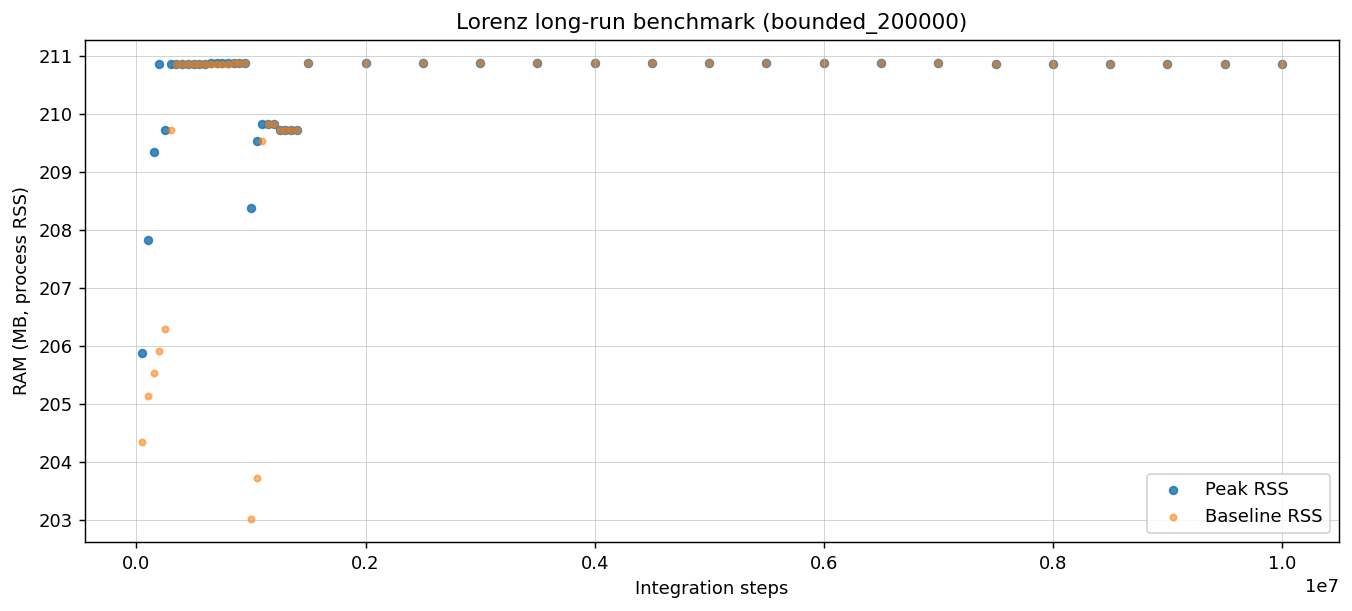

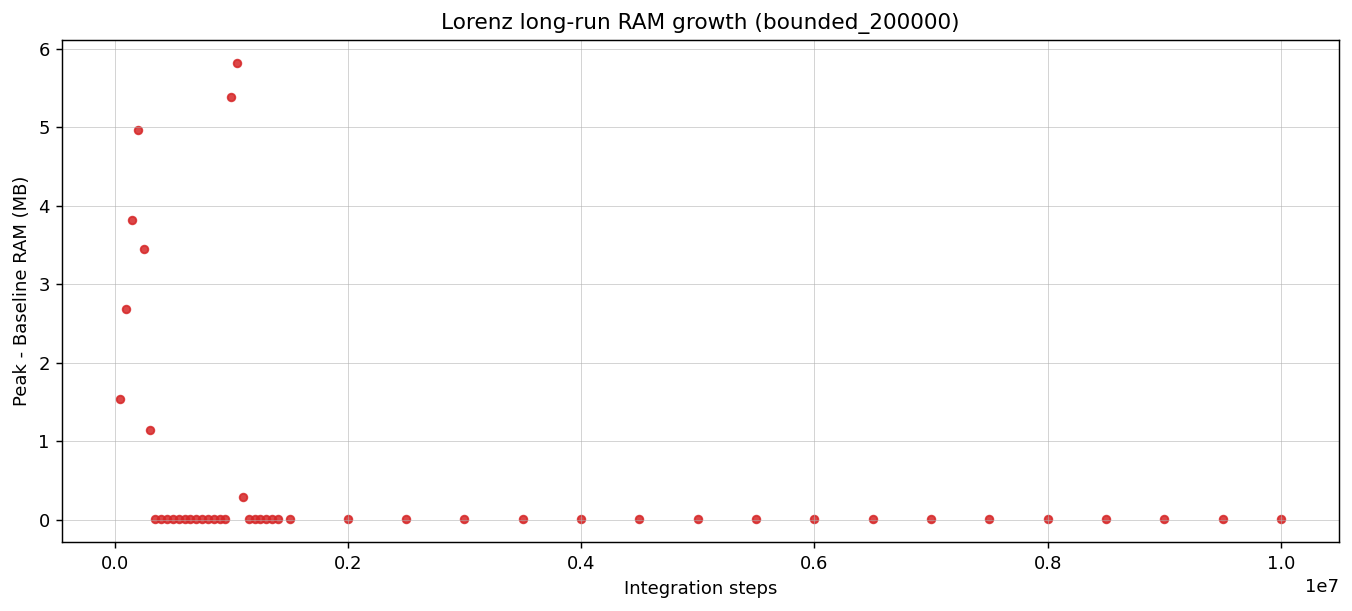

In [6]:
rows = sorted(load_rows(RESULTS_CSV), key=lambda r: int(r["n_steps"]))
if len(rows) == 0:
    raise RuntimeError(f"No rows found in {RESULTS_CSV}. Run benchmark cell first.")

steps = np.array([int(r["n_steps"]) for r in rows], dtype=np.int64)
baseline = np.array([float(r["baseline_rss_mb"]) for r in rows], dtype=float)
peak = np.array([float(r["peak_rss_mb"]) for r in rows], dtype=float)
delta = np.array([float(r["delta_peak_mb"]) for r in rows], dtype=float)

fig, ax = plt.subplots(figsize=(10.5, 4.8), dpi=130)
ax.scatter(steps, peak, s=18, alpha=0.85, label="Peak RSS")
ax.scatter(steps, baseline, s=12, alpha=0.55, label="Baseline RSS")
ax.set_xlabel("Integration steps")
ax.set_ylabel("RAM (MB, process RSS)")
ax.set_title(f"Lorenz long-run benchmark ({mode_label})")
ax.grid(True, linewidth=0.3)
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10.5, 4.8), dpi=130)
ax.scatter(steps, delta, s=18, alpha=0.85, color="tab:red")
ax.set_xlabel("Integration steps")
ax.set_ylabel("Peak - Baseline RAM (MB)")
ax.set_title(f"Lorenz long-run RAM growth ({mode_label})")
ax.grid(True, linewidth=0.3)
plt.tight_layout()
plt.show()
